# Análise Exploratória dos Dados — Cyclistic

Este notebook apresenta a análise exploratória do dataset processado da Cyclistic, com o objetivo de identificar padrões de utilização do serviço e diferenças de comportamento entre usuários **membros** e **casuais**.

A análise será realizada utilizando Python e Pandas, explorando características como perfil dos usuários, frequência de utilização, dias e horários de uso, duração das viagens e estações.

Os padrões identificados nesta etapa serão utilizados como base para as análises posteriores em SQL e para a construção do dashboard no Power BI.

## 1. Importação das bibliotecas necessárias

In [1]:
# Imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Carregamento do dataset processado

In [12]:
df = pd.read_parquet("../data/processed/cyclistic_202509_202608_processed.parquet")

## 3. Visão geral dos dados

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5951477 entries, 0 to 5951476
Data columns (total 17 columns):
 #   Column              Dtype          
---  ------              -----          
 0   ride_id             str            
 1   rideable_type       str            
 2   started_at          datetime64[us] 
 3   ended_at            datetime64[us] 
 4   start_station_name  str            
 5   start_station_id    str            
 6   end_station_name    str            
 7   end_station_id      str            
 8   start_lat           float64        
 9   start_lng           float64        
 10  end_lat             float64        
 11  end_lng             float64        
 12  member_casual       str            
 13  ride_length         timedelta64[us]
 14  day_of_week         int32          
 15  day_of_week_name    str            
 16  hour                int32          
dtypes: datetime64[us](2), float64(4), int32(2), str(8), timedelta64[us](1)
memory usage: 1.3 GB


In [14]:
df.describe()

,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,ride_length,day_of_week,hour
count,5951477,5951477,5.951477e+06,5.951477e+06,5.951477e+06,5.951477e+06,5951477,5.951477e+06,5.951477e+06
mean,2026-03-27 09:38:30.761242,2026-03-27 09:52:52.867894,4.190459e+01,-8.764695e+01,4.190500e+01,-8.764733e+01,0 days 00:14:22.124195,4.123608e+00,1.402444e+01
min,2025-08-31 10:57:37.782000,2025-09-01 00:00:02.434000,4.164000e+01,-8.791000e+01,4.151000e+01,-8.810000e+01,0 days 00:01:00.003000,1.000000e+00,0.000000e+00
25%,2025-11-13 10:46:07.483000,2025-11-13 10:57:01.465000,4.188275e+01,-8.766000e+01,4.188291e+01,-8.766000e+01,0 days 00:05:36.012000,2.000000e+00,1.000000e+01
50%,2026-05-06 19:08:48.098000,2026-05-06 19:21:00.902000,4.190000e+01,-8.764288e+01,4.190000e+01,-8.764322e+01,0 days 00:09:30.181000,4.000000e+00,1.500000e+01
75%,2026-07-09 15:25:36.704000,2026-07-09 15:40:03.164000,4.193000e+01,-8.763000e+01,4.193000e+01,-8.763000e+01,0 days 00:16:24.597000,6.000000e+00,1.800000e+01
max,2026-08-31 23:55:36.979000,2026-08-31 23:59:43.005000,4.207000e+01,-8.752000e+01,4.219000e+01,-8.737000e+01,0 days 23:59:58.557000,7.000000e+00,2.300000e+01
std,NaN,NaN,4.418608e-02,2.691774e-02,4.437996e-02,2.718475e-02,0 days 00:27:08.891272,1.986220e+00,5.012800e+00


In [15]:
df.describe(include="str")

,ride_id,rideable_type,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,day_of_week_name
count,5951477,5951477,5951477,5951477,5951477,5951477,5951477,5951477
unique,5951477,2,1976,1976,2020,2021,2,7
top,B0AD82B8A2556E7C,electric_bike,Navy Pier,CHI01747,Navy Pier,CHI01747,member,Sábado
freq,1,4123253,66991,66991,66720,66720,3870643,929619


In [16]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week,day_of_week_name,hour
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,Clark St & Schiller St,CHI00462,Montrose Harbor,CHI00427,41.91,-87.63,41.96,-87.64,member,0 days 00:20:05.950000,2,Segunda-feira,12
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,Ashland Ave & Grace St,CHI00503,Broadway & Waveland Ave,CHI00496,41.95,-87.67,41.95,-87.65,member,0 days 00:07:58.453000,2,Segunda-feira,1
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,Clark St & Fletcher St,CHI02137,Lakefront Trail & Bryn Mawr Ave,CHI00298,41.94,-87.65,41.98,-87.65,member,0 days 00:23:37.910000,2,Segunda-feira,7
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,Lakefront Trail & Bryn Mawr Ave,CHI00298,Clark St & Fletcher St,CHI02137,41.98,-87.65,41.94,-87.65,member,0 days 00:17:31.728000,2,Segunda-feira,9
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,Campbell Ave & Augusta Blvd,CHI02104,Morgan St & Polk St,CHI00372,41.90,-87.69,41.87,-87.65,member,0 days 00:15:31.221000,6,Sexta-feira,8


## 4. Análise do perfil dos usuários

### 4.1 Quantidade de viagens por tipo de usuário

In [17]:
df["member_casual"].value_counts()

member_casual
member    3870643
casual    2080834
Name: count, dtype: int64

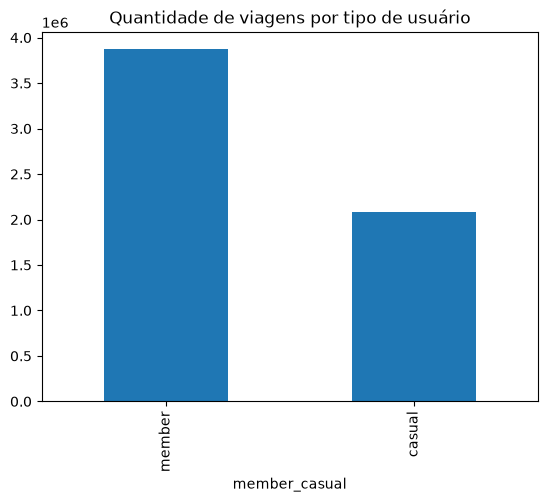

In [18]:
df["member_casual"].value_counts().plot(
    kind="bar",
    title="Quantidade de viagens por tipo de usuário"
);

### 4.2 Duração das viagens por tipo de usuário

In [19]:
df.groupby("member_casual")["ride_length"].apply(
    lambda x: x.dt.total_seconds().div(60).agg(["mean", "median"])
)

member_casual        
casual         mean      18.379657
               median    11.249800
member         mean      12.212490
               median     8.729583
Name: ride_length, dtype: float64

### 4.3 Tipos de bicicleta utilizados

In [20]:
pd.crosstab(
    df["member_casual"],
    df["rideable_type"]
)

rideable_type,classic_bike,electric_bike
member_casual,,
casual,565859,1514975
member,1262365,2608278


### 4.4 Perfil geral por usuário

In [21]:
df.groupby("member_casual").agg(
    viagens=("ride_id", "count"),
    duracao_media=("ride_length", lambda x: x.dt.total_seconds().div(60).mean()),
    duracao_mediana=("ride_length", lambda x: x.dt.total_seconds().div(60).median()),
    estacoes_origem=("start_station_name", "nunique"),
    estacoes_destino=("end_station_name", "nunique")
)

,viagens,duracao_media,duracao_mediana,estacoes_origem,estacoes_destino
member_casual,,,,,
casual,2080834,18.379657,11.249800,1907,1946
member,3870643,12.212490,8.729583,1902,1900
